# 🟡 Project - Medium · White Wine Quality as Regression with GBM

> **MLCourse · Machine Learning · supervised · regression**

### Business question
A Portuguese winery asks: *from physico-chemical lab tests alone - no human taster -
how precisely can we predict the sensory `quality` score (3-9)?* We treat quality as
a NUMBER (regression), benchmark honest baselines, and find out which lab measurements
drive taste.

### Inline plotting for Jupyter; plain-Python runs fall through harmlessly.


In [ ]:
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:            # no IPython here -> nothing to wire up
    pass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import urllib.request                                   # download-once helper
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

def find_data_dir() -> Path:
    here = Path.cwd()
    for candidate in [here, *here.parents]:             # walk up to the course root
        if candidate.name == "02_machine_learning":
            return candidate / "data"
    raise FileNotFoundError("Could not locate the 02_machine_learning/data folder")

DATA_DIR = find_data_dir()

WINE_CSV = DATA_DIR / "winequality-white.csv"
if not WINE_CSV.exists():                               # REAL UCI data, 4,898 wines
    urllib.request.urlretrieve(
        "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/"
        "winequality-white.csv", WINE_CSV)

df = pd.read_csv(WINE_CSV, sep=";")                     # UCI uses semicolons!
print(df.shape)
df.head(3)


### 1. EDA - an imbalanced target and a chemistry story


missing values: 0
quality
3      20
4     163
5    1457
6    2198
7     880
8     175
9       5
Name: count, dtype: int64


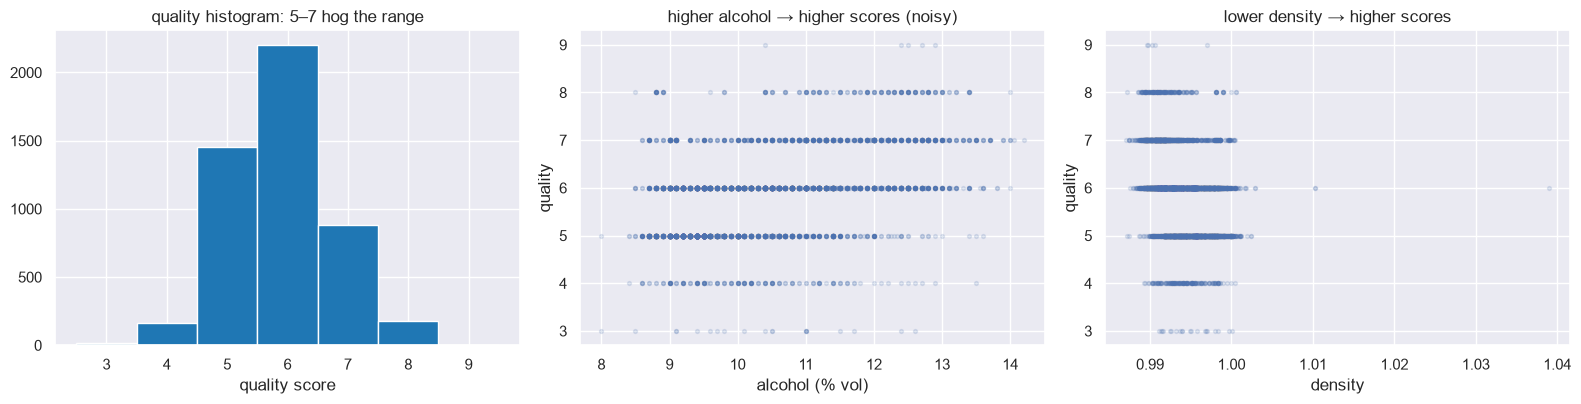

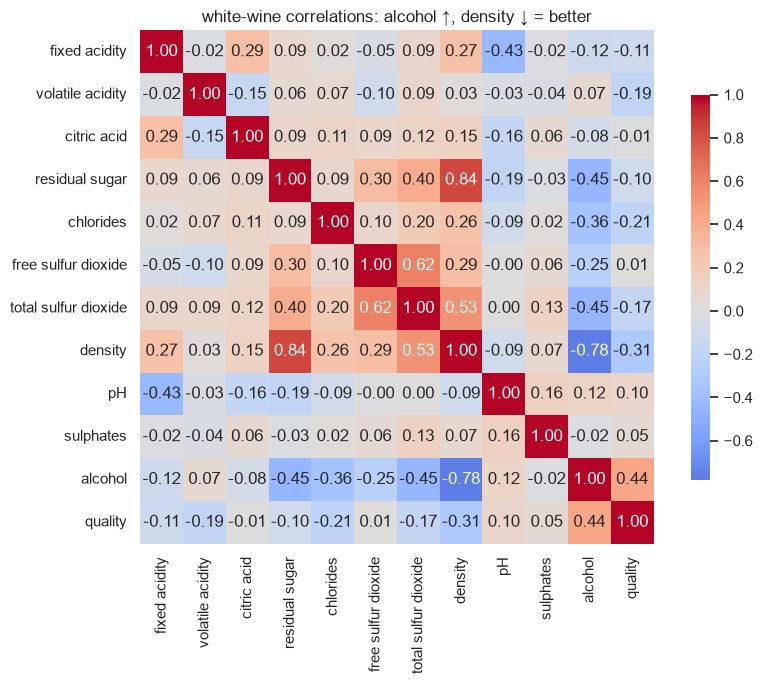

In [2]:
print("missing values:", int(df.isna().sum().sum()))     # expect 0
print(df["quality"].value_counts().sort_index())

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].hist(df["quality"], bins=np.arange(2.5, 10.5, 1), color="tab:blue",
             edgecolor="white")
axes[0].set_title("quality histogram: 5-7 hog the range")
axes[0].set_xlabel("quality score")

axes[1].scatter(df["alcohol"], df["quality"], s=8, alpha=0.15)
axes[1].set_xlabel("alcohol (% vol)"); axes[1].set_ylabel("quality")
axes[1].set_title("higher alcohol → higher scores (noisy)")

axes[2].scatter(df["density"], df["quality"], s=8, alpha=0.15)
axes[2].set_xlabel("density"); axes[2].set_ylabel("quality")
axes[2].set_title("lower density → higher scores")
plt.tight_layout(); plt.show()

plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            cbar_kws={"shrink": 0.75}, square=True)
plt.title("white-wine correlations: alcohol ↑, density ↓ = better")
plt.tight_layout(); plt.show()

### 2. Processing - nothing exotic, and that is a decision too

- All 11 features are numeric, no missing values → no imputation needed.
- Trees ignore feature scales → no scaling needed (a StandardScaler would change nothing).
- ⚠️ Quality is ORDINAL (3-9). Treating it as continuous is standard practice but means
  our model may output 5.7 - we will interpret predictions as "about a 6".
- No log-transform: features are mildly skewed but trees are scale-free.

In [3]:
X = df.drop(columns=["quality"])
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)               # stratify not needed for regression
print(f"train {X_train.shape} | test {X_test.shape}")

def met(y_true, pred):
    """All reported metrics in one place."""
    return {"R²": r2_score(y_true, pred),
            "MAE": mean_absolute_error(y_true, pred),
            "RMSE": mean_squared_error(y_true, pred) ** 0.5}

train (3918, 11) | test (980, 11)


### 3. Baselines: dummy + linear - then default GBM


In [4]:
results = {}
results["Dummy (mean)"] = met(y_test, np.full(len(y_test), y_train.mean()))
lin = LinearRegression().fit(X_train, y_train)
cv_lin = cross_val_score(lin, X_train, y_train, cv=5, scoring="r2")
results["Linear regression"] = met(y_test, lin.predict(X_test))

gbm_default = GradientBoostingRegressor(random_state=42).fit(X_train, y_train)
results["GBM defaults"] = met(y_test, gbm_default.predict(X_test))

summary = pd.DataFrame(results).T.round(3)
print(summary)
print(f"\nlinear 5-fold train-CV R²: {cv_lin.mean():.3f} ± {cv_lin.std():.3f}")
# 💡 Expect GBM defaults to beat linear by a wide margin - the alcohol/quality relation
#    flattens out at the top, which a straight line cannot express.

                      R²    MAE   RMSE
Dummy (mean)      -0.001  0.675  0.881
Linear regression  0.265  0.586  0.754
GBM defaults       0.404  0.536  0.680

linear 5-fold train-CV R²: 0.277 ± 0.016


### 4. Tuned GBM - small deliberate grid, CV on TRAIN only


In [5]:
param_grid = {
    "learning_rate": [0.03, 0.08],
    "max_depth": [2, 3, 4],          # shallow: interactions without memorising
    "n_estimators": [300, 800],      # pairs naturally with the learning rates above
}
search = GridSearchCV(
    GradientBoostingRegressor(subsample=0.8, random_state=42),
    param_grid, cv=5, scoring="r2", n_jobs=-1,
).fit(X_train, y_train)
print("best params:", search.best_params_)
final_gbm = search.best_estimator_
results[f"GBM tuned"] = met(y_test, final_gbm.predict(X_test))

pd.DataFrame(results).T.round(3)

best params: {'learning_rate': 0.08, 'max_depth': 4, 'n_estimators': 800}


,R²,MAE,RMSE
Dummy (mean),-0.001,0.675,0.881
Linear regression,0.265,0.586,0.754
GBM defaults,0.404,0.536,0.680
GBM tuned,0.512,0.450,0.615


### 5. Full metric panel + residual behaviour


              R²   MAE   RMSE
tuned GBM  0.512  0.45  0.615


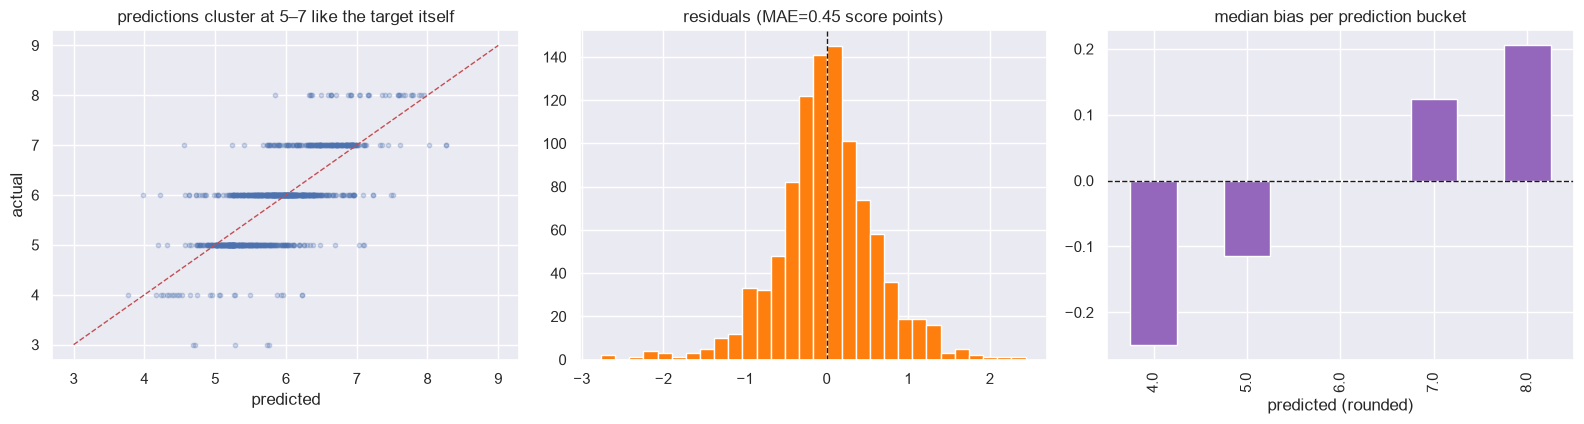

In [6]:
pred_test = final_gbm.predict(X_test)
panel = pd.DataFrame(met(y_test, pred_test), index=["tuned GBM"]).round(3)
print(panel)

resid = y_test - pred_test
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
axes[0].scatter(pred_test, y_test, s=10, alpha=0.25)
lims = [3, 9]
axes[0].plot(lims, lims, "r--", lw=1)
axes[0].set_xlabel("predicted"); axes[0].set_ylabel("actual")
axes[0].set_title("predictions cluster at 5-7 like the target itself")

axes[1].hist(resid, bins=30, color="tab:orange", edgecolor="white")
axes[1].axvline(0, color="k", ls="--", lw=1)
axes[1].set_title(f"residuals (MAE={met(y_test, pred_test)['MAE']:.2f} score points)")

binned = pd.DataFrame({"pred": pred_test.round(), "resid": resid})
binned.groupby("pred")["resid"].median().plot.bar(ax=axes[2], color="tab:purple")
axes[2].axhline(0, color="k", ls="--", lw=1)
axes[2].set_xlabel("predicted (rounded)")
axes[2].set_title("median bias per prediction bucket")
plt.tight_layout(); plt.show()
# 💡 The bias-by-bucket bars reveal systematic shrinkage: extreme wines (very good or
#    very bad) get pulled toward the middle - classic regression-to-the-mean.

### 6. What drives taste? Importances


C:\Users\Thoyajaksha Kashyap\AppData\Local\Temp\ipykernel_79328\1095462453.py:6: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
D:\projects\python\MLCourse\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


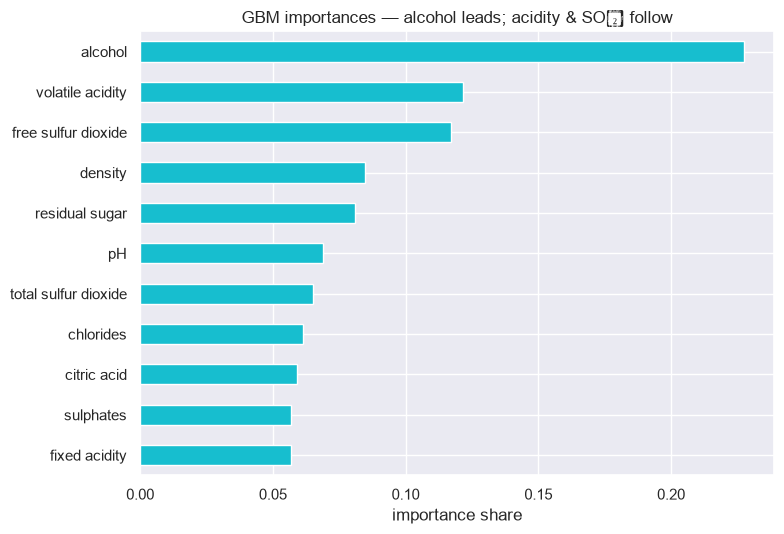

top-4: {'alcohol': 0.227, 'volatile acidity': 0.121, 'free sulfur dioxide': 0.117, 'density': 0.085}


In [7]:
imp = pd.Series(final_gbm.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(8, 5.5))
imp.plot.barh(color="tab:cyan")
plt.title("GBM importances - alcohol leads; acidity & SO₂ follow")
plt.xlabel("importance share")
plt.tight_layout(); plt.show()
print("top-4:", imp.sort_values(ascending=False).head(4).round(3).to_dict())
# Alcohol is the clear #1; volatile acidity (the 'vinegar' signal) and free sulfur
# dioxide come next, with density just behind - directionally consistent with EDA.

### 7. Findings & limitations

**Findings**
- Lab chemistry alone predicts taster scores to within about half a point of MAE -
  useful as a pre-screening tool before human panels.
- Alcohol content is the #1 driver; volatile acidity (the "vinegar" signal) and
  sulfur handling follow, with density (sugar body) close behind.
- Boosting clearly beats both the dummy and linear baselines; most remaining error
  is irreducible disagreement between human tasters.

**Limitations**
- ⚠️ Ordinal target treated as interval: predicting "5.7" is fine operationally, but
  classification-style reporting would need thresholds and different metrics.
- Severe class imbalance (only tiny minorities at 3, 4, 8, 9): metrics are dominated
  by ordinary 5-7 wines; performance at the extremes is much worse than the averages.
- Red-wine results do NOT transfer directly (different chemistry baseline).
- R² ≈ 0.5 looks modest by tabular-data standards, but for subjective sensory data
  this nears the practical ceiling - do not chase it with deeper models blindly.

### Summary takeaways

- Read the UCI separator (`sep=';'`) before blaming your loader.
- Benchmark dummy → linear → default GBM → tuned GBM: each step's increment tells
  you where complexity pays.
- Bias-per-bucket plots expose shrinkage-to-the-mean that aggregate metrics hide.
- When importances echo raw EDA directions (alcohol ↑ good, density ↓ good),
  trust the model enough to act on it.